<a href="https://colab.research.google.com/github/Elwing-Chou/ximen_ai_20260706/blob/main/ximen20260706.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. markdown語法: .md

2. latex math

$ \sigma = \sqrt {\frac{1}{n} \sum_{i=n} (x_i - \mu) ^ 2} $

In [1]:
a = 3
print(a)

3


1. 統計重點: 輸入(x) 輸出(y) -> 建立他們的方程式

2. 輸出
   1. 分類問題(Classfication): 輸出是選擇題
   2. 回歸問題(Regression): 輸出是計算題(數值)
   3. 分群問題(Cluster): 沒有輸出(把輸出和方程式都建立起來)(深度學習沒有)

3. python常用機器學習函式庫
    1. scikit-learn: 最常用, 別名sklearn
    2. numpy: 很少直接用到, 矩陣運算
    3. scipy: 比較少用到, 你的統計量是比較少用, e.g. skewness/box-cox轉換
    4. pandas: 超級常用, 處理表格
    5. matplotlib: 畫圖基礎
    6. seaborn: 進階畫圖函式庫

In [2]:
# Step 1. 把你的資料整理成一個表格
# 並且先存一份CSV(comma-separated values) TSV(Tab-separated)
# 逗號分隔每一格, 用換行分隔每一筆
import pandas as pd
from sklearn.datasets import load_iris

data = load_iris()
# pandas型態: DataFrame(表格) Series(一行/一列)
# 橫: rows/列 直: columns/行
df = pd.DataFrame(data["data"],
                  columns=data["feature_names"])
df["target"] = data["target"]
df.to_csv("iris.csv", encoding="utf-8", index=False)
# index列標籤
# index=True read_csv(index_col=0)
# index=False read_csv()
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
# Step 2. 評估一下你的資料到底夠不夠
# 機器學習: 千筆以上
# 深度學習: 萬筆以上
# 問題複雜度: 複雜度(有效輸入越多個)越高, 越多資料

# Step 3. 分成兩部分
# 1. 訓練資料(給你的模型訓練)  2. 驗證資料(驗證模型用)
from sklearn.model_selection import train_test_split
# train_test_split([1, 2, 3, 4],
#                  [5, 6, 7, 8],
#                  [10, 11, 12, 13],
#                  test_size=0.25)
# x, y分出來
# drop():  pandas只要看到axis參數, 只有兩種0 和 1, 不同方向
# demo = pd.DataFrame([
#     [1, 2],
#     [3, 4]
# ], columns=["a", "b"], index=["a", "b"])
# demo.drop("a", axis=1)
x = df.drop("target", axis=1)
y = df["target"]
# x 80, x 20, y 80, y 20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
y_train

,target
46,0
106,2
99,1
83,1
51,1
...,...
107,2
114,2
61,1
72,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
# 過擬合: 任何模型都要防止, 防止過度學習訓練資料
# 因為過度學習訓練資料,
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

[Text(0.5, 0.9166666666666666, 'petal width (cm) <= 0.8\ngini = 0.665\nsamples = 120\nvalue = [38, 38, 44]\nclass = virginica'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 38\nvalue = [38, 0, 0]\nclass = setosa'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'petal width (cm) <= 1.75\ngini = 0.497\nsamples = 82\nvalue = [0, 38, 44]\nclass = virginica'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.21\nsamples = 42\nvalue = [0, 37, 5]\nclass = versicolor'),
 Text(0.15384615384615385, 0.4166666666666667, 'sepal length (cm) <= 4.95\ngini = 0.054\nsamples = 36\nvalue = [0, 35, 1]\nclass = versicolor'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 35\nvalue = [0, 35, 0]\nclass = versicolor'),
 Text(0.46153846153846156, 0.41666666666

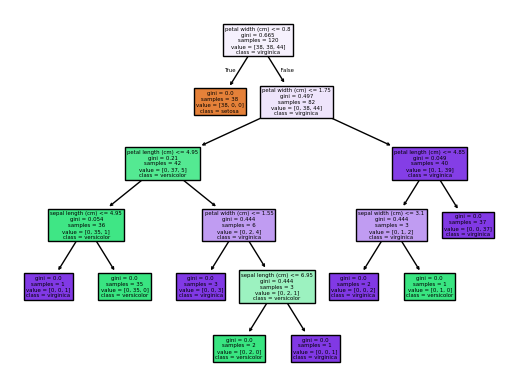

In [11]:
from sklearn.tree import plot_tree
plot_tree(clf,
          feature_names=x.columns,
          filled=True,
          class_names=data["target_names"])